# **MNIST DATASET**

In [ ]:
from __future__ import absolute_import, division, print_function

import tensorflow as tf
import numpy as np

In [ ]:
# MNIST dataset parametrs
num_classes = 10 # Total classes (0-9 digit)
num_features = 784 # data features in our input (28*28=784)

In [ ]:
# Training parameters
learning_rate = 0.001
training_step = 3000
display_step = 100
batch_size = 256

In [ ]:
# Neural Network Parameters
n_hidden_1 = 128 # 1st layer number of neurons
n_hidden_2 = 256 # 2nd layer number of neurons

In [ ]:
# Prepare MNIST data

# Download the dataset

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# convert to float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Flatten images to 1-D vector of 784 features(28*28)
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Normalize image values from [0-255] ----> [0-1]
x_train, x_test = x_train / 255. , x_test / 255.

In [ ]:
# Use tf.data API to shuffle and batch data
train_data = tf.data.Dataset.from_tensor_slices((x_train,y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [ ]:
# stores layers weights and biases
# A random number generator to intialize weights

random_normal = tf.initializers.RandomNormal()

weights = {
    'h1': tf.Variable(random_normal ([num_features,  n_hidden_1])),
    'h2': tf.Variable(random_normal ([n_hidden_1, n_hidden_2])),
    'out': tf.Variable(random_normal ([n_hidden_2, num_classes]))
}

biases = {
    'b1':tf.Variable(random_normal ([n_hidden_1])),
    'b2':tf.Variable(random_normal ([n_hidden_2])),
    'out':tf.Variable(random_normal ([num_classes]))
}

In [ ]:
print('shape w_1:',weights['h1'].shape)
print('shape w_2:',weights['h2'].shape)
print('shape w_out:',weights['out'].shape)

print('shape b_1:', biases['b1'].shape)
print('shape b_2:', biases['b2'].shape)
print('shape b_out:',biases['out'].shape)

shape w_1: (784, 128)
shape w_2: (128, 256)
shape w_out: (256, 10)
shape b_1: (128,)
shape b_2: (256,)
shape b_out: (10,)


In [ ]:
# Create model

def neural_net(x):
  # Hidden fully connected layer with 128 neuron
  layer_1 = tf.add(tf.matmul(x,weights["h1"]),biases['b1'])  # Z1
  # apply sigmoid to layer_1 output for non-linearity
  layer_1 = tf.nn.sigmoid(layer_1) #A1

  # Hidden fully connected layer with 256
  layer_2 = tf.add(tf.matmul(layer_1,weights["h2"]),biases['b2'])  # Z2

  # Apply sigmoid to layer_2 output
  layer_2 = tf.nn.sigmoid(layer_2) #A2

  # Output fully connected layer with a nuron for each classes ---->10

  out_layer = tf.matmul(layer_2,weights['out'])+biases['out']  # Z3 output layer

  # Apply soft max activation function to normalize the digits to probability distribution
  return tf.nn.softmax(out_layer)

In [ ]:
## Cross-Entropy Loss function
def Cross_entropy(y_pred, y_true):
  # Encode label to a one hot vector
  t_true = tf.one_hot(y_true, depth = num_classes)

  # clip prediction values to avoid log(0) error
  y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

  # Compute cross-entropy loss
  return tf.reduce_mean(-tf.reduce_sum(t_true * tf.math.log(y_pred)))

  # Accuracy metrics
def accuracy(y_pred, y_true):
  # predicted class is the index of highest score in prediction vector(ie argmax )
  correct_prediction = tf.equal(tf.argmax(y_pred, 1), tf.cast(y_true, tf.int64))
  return tf.reduce_mean(tf.cast(correct_prediction, tf.float32), axis= -1)

# Stochastic gradient descent optimizer
optimizer = tf.optimizers.SGD(learning_rate)
optimizer

In [ ]:
# Optimizing process
def run_optimization(x,y):
  # Wrap computation inside a GradientTap for automatic differntiation

  with tf.GradientTape() as g:
    pred = neural_net(x)
    loss = Cross_entropy(pred,y)

  # Variable to update i.e trainable variable during back propagation
  trainable_variables = list(weights.values())+list(biases.values())

  # Compute graidents
  gradients = g.gradient(loss,trainable_variables)

  # Update w and b following gradients
  optimizer.apply_gradients(zip(gradients,trainable_variables))

In [ ]:
# Run training for the given number of steps
for step, (batch_x,batch_y) in enumerate(train_data.take(training_step),1):
  # Run the optimization top update w and b values after each batch
  run_optimization(batch_x,batch_y)

  if step % display_step ==0:
    pred = neural_net(batch_x)
    loss = Cross_entropy(pred,batch_y)
    acc = accuracy(pred,batch_y)
    print(f"step:{step}, loss: {loss}, accuracy: {acc}" )

step:100, loss: 563.768798828125, accuracy: 0.390625
step:200, loss: 427.5849914550781, accuracy: 0.51171875
step:300, loss: 251.4967041015625, accuracy: 0.71484375
step:400, loss: 169.40866088867188, accuracy: 0.8203125
step:500, loss: 149.22744750976562, accuracy: 0.85546875
step:600, loss: 124.46966552734375, accuracy: 0.875
step:700, loss: 111.18404388427734, accuracy: 0.88671875
step:800, loss: 110.27394104003906, accuracy: 0.875
step:900, loss: 117.12647247314453, accuracy: 0.859375
step:1000, loss: 118.92049407958984, accuracy: 0.87109375
step:1100, loss: 73.29096984863281, accuracy: 0.9375
step:1200, loss: 68.74935150146484, accuracy: 0.92578125
step:1300, loss: 93.12995910644531, accuracy: 0.90625
step:1400, loss: 58.67890167236328, accuracy: 0.92578125
step:1500, loss: 55.313720703125, accuracy: 0.94921875
step:1600, loss: 65.5888900756836, accuracy: 0.921875
step:1700, loss: 84.07276153564453, accuracy: 0.88671875
step:1800, loss: 116.51517486572266, accuracy: 0.875
step:190

In [ ]:
# Test mode on validations set
pred = neural_net(x_test)
print(f"Test Accuracy: {accuracy(pred ,y_test)}")

Test Accuracy: 0.9373999834060669


In [ ]:
# Visual prediction comparison
import matplotlib.pyplot as plt

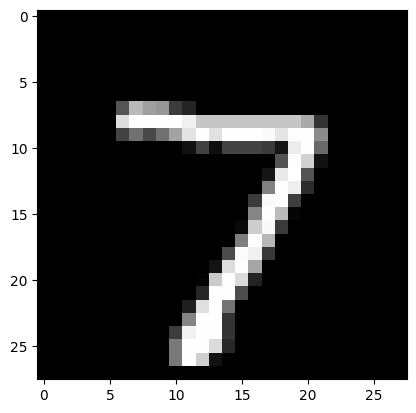

Model Prediction 7


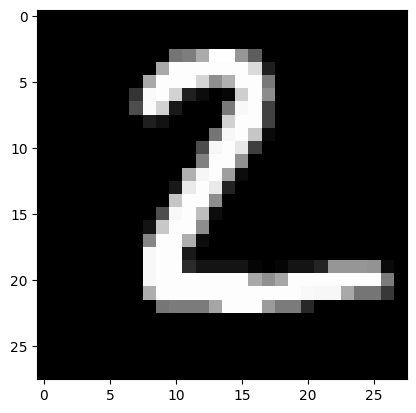

Model Prediction 2


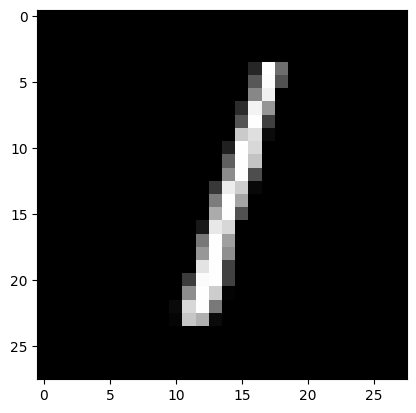

Model Prediction 1


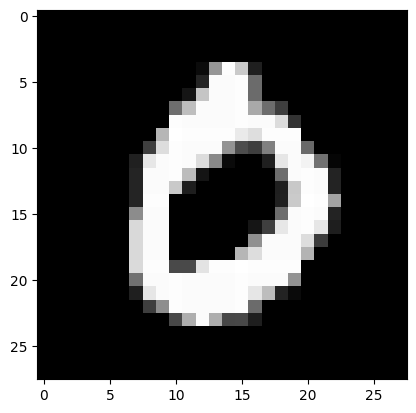

Model Prediction 0


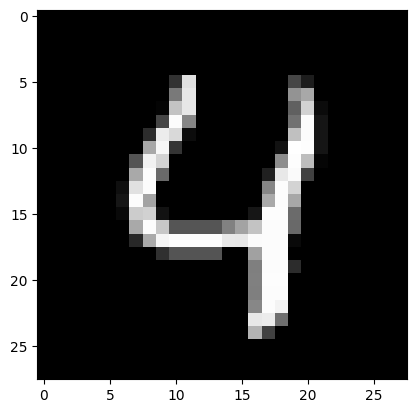

Model Prediction 4


In [ ]:
# Predict 5 images from tha validation set
n_images = 5
test_images = x_test[:n_images]
# Shape = [5, 784]

predictions = neural_net(test_images)
# [5, 10]

# Display image and model predictions
for i in range (n_images):
  plt.imshow(np.reshape(test_images[i], [28,28]), cmap = 'grey')
  plt.show()
  print(f"Model Prediction {np.argmax(predictions.numpy()[i])}")